In [ ]:
!pip install diffusers transformers accelerate torch pillow


In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import os

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")

output_dir = "synthetic_dataset"
os.makedirs(output_dir, exist_ok=True)

prompts = [
    "People playing cricket near a river",
    "Dogs dressed as people doing shopping",
    "A robotic humanoid reading a book in a library",
    "A cyberpunk street with flying cars",
    "A realistic painting of a cat wearing royal clothes"
]

for i, prompt in enumerate(prompts):
    image = pipe(prompt).images[0]
    image.save(f"{output_dir}/image_{i+1}.png")

print("Synthetic dataset generated successfully!")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Synthetic dataset generated successfully!


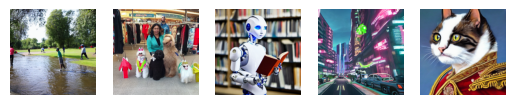

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

for i in range(1, 6):
    img = Image.open(f"synthetic_dataset/image_{i}.png")
    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.axis("off")

